# Phase 3 Step 2a — 종목별 LSTM 학습 (`02a_phase15_stockwise_extended.ipynb`)

> **목적**: Phase 1.5 v8 Performance-Weighted Ensemble 을 17 년 (2009~2025) **전체 S&P 500 universe** (~624 종목) 에
>          4-way 병렬 (RTX 4090 24GB) 로 학습·예측.

## 모델 구성 (Phase 1.5 v8 일관)

- **LSTM v4** (3ch_vix: rv_d, rv_w, rv_m + vix_log, IS=1250, embargo=63, hidden=32)
- **HAR-RV** (1d, 5d, 22d 이동평균 선형 회귀)
- **Ensemble** = Performance-Weighted (Diebold-Pauly rolling)

## 진행 상황 가시화 (재설계, 2026-04-29)

- `tqdm.auto` 진행 막대 (notebook + CMD 양쪽)
- 종목 완료마다 ETA·경과시간 출력 (`flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장

## 실행 전 확인

1. `01_universe_extended.ipynb` 완료 (`universe_full_history.csv` + `daily_panel.csv`, 624 종목)
2. RTX 4090 24GB GPU 가용
3. CUDA + PyTorch 정상

## 산출물

| 파일 | 내용 |
|---|---|
| `data/ensemble_predictions_stockwise.csv` | 종목별 예측 (date, ticker, y_pred_lstm, y_pred_har, y_pred_ensemble, y_true) |

## 예상 시간

- **624 종목 × 4-way 병렬 (RTX 4090)**: 약 3~5 시간
- 8-way 대비 4-way: CUDA 컨텍스트 overhead ↓, 동일 또는 더 빠름

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + 경로 |
| §2 | GPU 환경 확인 |
| §3 | 4-way 병렬 학습 실행 |
| §4 | 결과 검증 (RMSE 분포, best model 분포) |
| §5 | Phase 2 결과 비교 (공통 종목) |

## §1. 환경 부트스트랩

In [56]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '02a_stockwise'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02a_stockwise


## §2. GPU 환경 확인

In [57]:
import torch

print('=== GPU 환경 ===')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_mem = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)) / 1e9
    print(f'Total VRAM: {total_mem:.1f} GB')
    print(f'Free  VRAM: {free_mem:.1f} GB')
    assert free_mem >= 3.0, f'VRAM 부족: {free_mem:.1f} GB < 3 GB'
    print('✅ GPU 조건 충족')
else:
    print('⚠️ CPU 모드 (매우 느림)')

=== GPU 환경 ===
PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Total VRAM: 25.8 GB
Free  VRAM: 25.8 GB
✅ GPU 조건 충족


## §3. 8-way 병렬 학습 (V4_BEST_CONFIG, 전체 S&P 500)

`run_ensemble_for_universe_parallel()`:
- `n_workers=8` → CPU 병목 환경에서 최대 throughput
  - VRAM: 8 워커 × ~800MB = 6.4GB (24GB 중 여유)
- `tqdm.auto` 진행 막대 + 종목별 완료 로그 (실시간, `flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장
- 학습 시간: 약 2~3 시간 (624 종목 / 8 workers / 종목당 ~100~120초)

> 💡 노트북에서 실행 시 진행률이 실시간 표시됩니다 (tqdm + flush).
> CMD `nbconvert` 실행 시에도 동일하게 출력됩니다.

In [58]:
from scripts.volatility_ensemble import run_ensemble_for_universe_parallel, V4_BEST_CONFIG

print('=== 하이퍼파라미터 ===')
for k, v in V4_BEST_CONFIG.items():
    print(f'  {k}: {v}')

=== 하이퍼파라미터 ===
  input_channels: 3ch_vix
  hidden_size: 32
  num_layers: 1
  dropout: 0.3
  lr: 0.001
  weight_decay: 0.001
  loss_type: mse
  huber_delta: 0.01
  max_epochs: 50
  early_stop_patience: 10
  lr_patience: 5
  lr_factor: 0.5
  batch_size: 64
  is_len: 1250
  seq_len: 63
  embargo: 63
  oos_len: 21
  step: 21
  window: 21
  har_w: 5
  har_m: 22


In [59]:
# 데이터 확인 (전체 S&P 500 universe)
panel_path = DATA_DIR / 'daily_panel.csv'
universe_path = DATA_DIR / 'universe_full_history.csv'  # ⭐ 624 종목 universe

assert panel_path.exists(), f'panel 없음: {panel_path}'
assert universe_path.exists(), f'universe 없음: {universe_path}'

panel_info = pd.read_csv(panel_path, usecols=['date', 'ticker'], parse_dates=['date'])
uni_info = pd.read_csv(universe_path)
print(f'panel: {len(panel_info):,} 행, {panel_info["ticker"].nunique()} 종목')
print(f'universe: {uni_info["ticker"].nunique()} unique 종목 (전체 S&P 500 모드)')

panel: 3,344,502 행, 646 종목
universe: 809 unique 종목 (전체 S&P 500 모드)


In [60]:
# ⭐ 8-way 병렬 학습 실행 (전체 S&P 500, 624 종목)
# ⭐ 캐시 추가 (2026-04-30): 학습 결과 csv 가 있으면 로드, 없으면 재학습
#   목적: VS Code Run All / 실수 클릭 시 GPU 재학습 (~수~십수 시간) 방지
import pandas as pd

out_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
FORCE_RETRAIN = False    # ⭐ True 시 캐시 무시 + 재학습 (8-way GPU, ~수 시간)

if out_path.exists() and not FORCE_RETRAIN:
    print(f'⚡ 학습 결과 캐시 사용: {out_path.name} (재학습 생략)')
    print(f'  강제 재학습: FORCE_RETRAIN = True 변경 후 재실행 (GPU 비용 큼)')
    ensemble_sw = pd.read_csv(out_path, parse_dates=['date'])
    print(f'  ensemble_sw: {ensemble_sw.shape}')
    print(f'  unique 종목: {ensemble_sw["ticker"].nunique()}')
else:
    if FORCE_RETRAIN:
        print('⚠️ FORCE_RETRAIN=True → 8-way GPU 재학습 (~수 시간)')

    # 진행률은 tqdm.auto + flush=True 로 실시간 표시
    t0 = time.time()

    ensemble_sw = run_ensemble_for_universe_parallel(
        panel_csv=panel_path,
        universe_csv=universe_path,        # ⭐ universe_full_history.csv (624 종목)
        out_dir=DATA_DIR,
        config=V4_BEST_CONFIG,
        n_workers=8,                        # RTX 4090 24GB, CPU 병목 환경
        out_name='ensemble_predictions_stockwise.csv',
        verbose=True,
    )

    elapsed = time.time() - t0
    print(f'\n⏱️ 총 소요 시간: {elapsed/60:.1f} 분')

print(f'결과: {ensemble_sw.shape}')
ensemble_sw.head()

⚡ 학습 결과 캐시 사용: ensemble_predictions_stockwise.csv (재학습 생략)
  강제 재학습: FORCE_RETRAIN = True 변경 후 재실행 (GPU 비용 큼)
  ensemble_sw: (2468770, 9)
  unique 종목: 613
결과: (2468770, 9)


,date,ticker,fold,y_true,y_pred_lstm,y_pred_har,w_v4,w_har,y_pred_ensemble
0,2007-04-23,A,0,-3.990928,-4.118109,-4.358518,0.500000,0.500000,-4.238313
1,2007-04-24,A,0,-3.992709,-4.091316,-4.434871,0.500000,0.500000,-4.263093
2,2007-04-25,A,0,-3.945503,-4.077171,-4.475481,0.500000,0.500000,-4.276326
3,2007-04-26,A,0,-3.934768,-4.070193,-4.493251,0.500000,0.500000,-4.281722
4,2007-04-27,A,0,-3.947074,-4.078562,-4.458112,0.500000,0.500000,-4.268337


In [61]:
import pandas as pd, numpy as np
from scripts.setup import DATA_DIR

fold_results = pd.read_csv(DATA_DIR / 'fold_predictions_stockwise.csv', parse_dates=['date'])

# inf 종목 식별
inf_lstm = fold_results[np.isinf(fold_results['y_pred_lstm'])]
inf_har = fold_results[np.isinf(fold_results['y_pred_har'])]
print(f'LSTM inf 행: {len(inf_lstm)} / {fold_results["ticker"].nunique()} 종목 영향')
print(f'HAR  inf 행: {len(inf_har)} / 영향 종목: {inf_har["ticker"].unique()}')

# 매우 큰 값 확인
for col in ['y_pred_lstm', 'y_pred_har']:
    extreme = fold_results.nlargest(5, col)[['ticker', 'fold', 'date', col, 'y_true']]
    print(f'\n{col} 극단값 top 5:')
    print(extreme)

LSTM inf 행: 0 / 615 종목 영향
HAR  inf 행: 0 / 영향 종목: []

y_pred_lstm 극단값 top 5:
        ticker  fold       date  y_pred_lstm   y_true
2170350    TIE   103 2015-11-25     1.645716 1.313152
2170360    TIE   103 2015-12-10     1.604853 0.589162
2170351    TIE   103 2015-11-27     1.592367 1.313152
2170352    TIE   103 2015-11-30     1.586052 1.313152
2170361    TIE   103 2015-12-11     1.577543 0.589481

y_pred_har 극단값 top 5:
       ticker  fold       date  y_pred_har   y_true
395229    CBE   124 2017-09-29    1.606147 1.182046
395234    CBE   124 2017-10-06    1.600474     -inf
395228    CBE   124 2017-09-28    1.581314 1.376779
395233    CBE   124 2017-10-05    1.577390 0.811077
395201    CBE   123 2017-08-21    1.550823 1.956935


In [62]:
# 들여쓰기 확인 (수정 직후)
import inspect
from scripts.volatility_ensemble import compute_performance_weights
src = inspect.getsource(compute_performance_weights)
# 'out_rows.append' 가 'for k in folds_unique:' 보다 깊은 들여쓰기에 있어야 함
print(src)

def compute_performance_weights(
    fold_results: pd.DataFrame,
    initial_weights: Optional[dict] = None,
) -> pd.DataFrame:
    """Performance-Weighted ensemble 가중치 + 예측 계산.

    Parameters
    ----------
    fold_results : pd.DataFrame
        columns: date, ticker, fold, y_true, y_pred_lstm, y_pred_har
    initial_weights : dict | None
        {'w_v4': float, 'w_har': float} 첫 fold warmup. None 시 0.5/0.5.

    Returns
    -------
    pd.DataFrame
        + columns: w_v4, w_har, y_pred_ensemble

    Notes
    -----
    공식 (Phase 1.5 v8 Performance-Weighted, Diebold-Pauly 1987):
        w_v4[k]  = (1/RMSE_v4[k-1]) / (1/RMSE_v4[k-1] + 1/RMSE_har[k-1])
        w_har[k] = 1 - w_v4[k]
        y_pred_ensemble[k] = w_v4[k] · y_pred_lstm[k] + w_har[k] · y_pred_har[k]

    첫 fold (k=0): initial_weights 사용 (default 0.5/0.5).
    """
    df = fold_results.sort_values(["ticker", "fold", "date"]).copy()

    # ⭐ non-finite 행 제거 (target 또는 예측 폭주 종목 — 폐상장 등 stale price)
    n_before = len(df)
  

In [63]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
from scripts.setup import DATA_DIR
from scripts.volatility_ensemble import compute_performance_weights

# 1) fold_predictions_stockwise.csv 로드
fold_results = pd.read_csv(
    DATA_DIR / 'fold_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'fold_results: {fold_results.shape}')

# 2) -inf 진단 (수정된 함수 적용 전 확인용)
neg_inf_count = (fold_results['y_true'] == -np.inf).sum()
print(f'\\ny_true == -inf 행: {neg_inf_count}')
if neg_inf_count > 0:
    bad = fold_results[fold_results['y_true'] == -np.inf]
    print(f'  영향 종목: {sorted(bad["ticker"].unique())}')

# 3) Performance ensemble 재계산 (수정된 함수가 자동 필터링)
ensemble_df = compute_performance_weights(fold_results)
print(f'\\nensemble_df: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')

# 4) 저장
out_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
ensemble_df.to_csv(out_path, index=False)
print(f'✅ 저장: {out_path}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fold_results: (2493981, 6)
\ny_true == -inf 행: 1100
  영향 종목: ['AMCR', 'BMC', 'CBE', 'COL', 'CPWR', 'CVG', 'EP', 'GR', 'MEE', 'SW']
  [compute_performance_weights] 25211/2493981 행 제거 (non-finite y_true/pred). 영향 종목: ['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN', 'ANDV', 'ANET', 'ANF', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATI', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBBY', 'BBWI', 'BBY', 'BDX', 'BEAM', 'BEN', 'BF-B', 'BG', 'BHF', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMC', 'BMS', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BTU', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR',

Performance ensemble:   0%|                                                 | 0/613 [00:00<?, ?it/s]

\nensemble_df: (2468770, 9)
  unique 종목: 613
✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv


In [64]:
# ensemble_df 검증
print(f'ensemble_df.shape: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')
print(f'  date 범위: {ensemble_df["date"].min().date()} ~ {ensemble_df["date"].max().date()}')

# 컬럼 검증
expected_cols = {'date', 'ticker', 'fold', 'y_true', 'y_pred_lstm',
                  'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble'}
print(f'\\n컬럼: {list(ensemble_df.columns)}')
print(f'  expected ⊆ actual: {expected_cols.issubset(ensemble_df.columns)}')

# NaN 통계
for col in ['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']:
    n_nan = ensemble_df[col].isna().sum()
    print(f'  {col}: NaN={n_nan}')

# 가중치 평균
print(f'\\n가중치 평균:')
print(f'  w_v4 (LSTM): {ensemble_df["w_v4"].mean():.3f}')
print(f'  w_har:       {ensemble_df["w_har"].mean():.3f}')
print(f'  합계:         {(ensemble_df["w_v4"] + ensemble_df["w_har"]).mean():.3f} (≈ 1.000 기대)')

ensemble_df.shape: (2468770, 9)
  unique 종목: 613
  date 범위: 2007-04-23 ~ 2025-12-01
\n컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  expected ⊆ actual: True
  y_pred_lstm: NaN=0
  y_pred_har: NaN=0
  y_pred_ensemble: NaN=0
  y_true: NaN=0
\n가중치 평균:
  w_v4 (LSTM): 0.489
  w_har:       0.511
  합계:         1.000 (≈ 1.000 기대)


## §4. 결과 검증

In [65]:
# 복구 셀: 저장된 CSV 를 ensemble_sw 변수로 로드
import pandas as pd
from scripts.setup import DATA_DIR

ensemble_sw = pd.read_csv(
    DATA_DIR / 'ensemble_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'ensemble_sw 로드: {ensemble_sw.shape}')
print(f'  unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'  컬럼: {list(ensemble_sw.columns)}')

ensemble_sw 로드: (2468770, 9)
  unique 종목: 613
  컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']


In [66]:
# 4-1. 기본 통계
print('=== 산출 CSV 기본 통계 ===')
print(f'행 수: {len(ensemble_sw):,}')
print(f'unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'unique fold: {ensemble_sw["fold"].nunique()}')
print(f'date 범위: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('컬럼별 NaN 수:')
print(ensemble_sw[['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']].isna().sum())

=== 산출 CSV 기본 통계 ===
행 수: 2,468,770
unique 종목: 613
unique fold: 224
date 범위: 2007-04-23 ~ 2025-12-01

컬럼별 NaN 수:
y_pred_lstm        0
y_pred_har         0
y_pred_ensemble    0
y_true             0
dtype: int64


In [67]:
# 4-2. 종목별 RMSE 계산
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))

rmse_by_ticker = ensemble_sw.groupby('ticker').apply(
    lambda df: pd.Series({
        'rmse_lstm': rmse(df['y_true'].values, df['y_pred_lstm'].values),
        'rmse_har': rmse(df['y_true'].values, df['y_pred_har'].values),
        'rmse_ensemble': rmse(df['y_true'].values, df['y_pred_ensemble'].values),
    })
).reset_index()

print('=== 종목별 RMSE 통계 ===')
print(rmse_by_ticker[['rmse_lstm', 'rmse_har', 'rmse_ensemble']].describe())

=== 종목별 RMSE 통계 ===
       rmse_lstm   rmse_har  rmse_ensemble
count 613.000000 613.000000     613.000000
mean    0.528874   0.401487       0.390809
std     0.148154   0.140970       0.117644
min     0.240331   0.231106       0.233678
25%     0.448174   0.361721       0.355457
50%     0.515405   0.388942       0.379556
75%     0.584463   0.416219       0.404015
max     2.046953   3.079804       2.276586


=== Best 모델 분포 ===
ensemble    398
har         200
lstm         15
Name: count, dtype: int64


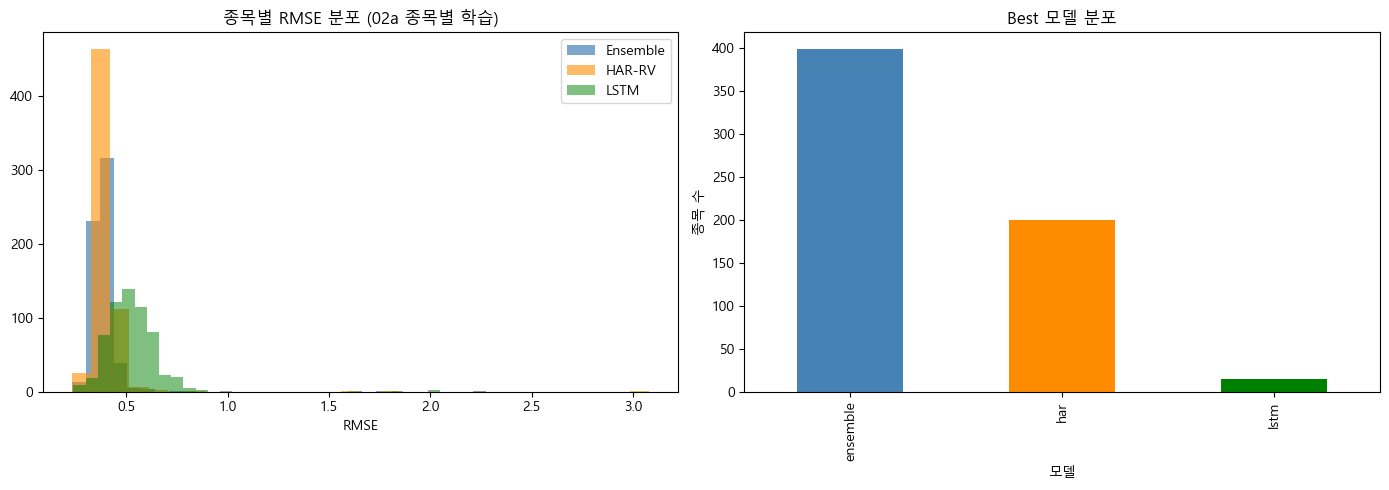

In [68]:
# 4-3. Best 모델 분포
best_model = rmse_by_ticker.apply(
    lambda row: 'lstm' if row['rmse_lstm'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
               else ('har' if row['rmse_har'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
                    else 'ensemble'),
    axis=1
)
print('=== Best 모델 분포 ===')
print(best_model.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 분포
axes[0].hist(rmse_by_ticker['rmse_ensemble'], bins=30, alpha=0.7, label='Ensemble', color='steelblue')
axes[0].hist(rmse_by_ticker['rmse_har'], bins=30, alpha=0.6, label='HAR-RV', color='darkorange')
axes[0].hist(rmse_by_ticker['rmse_lstm'], bins=30, alpha=0.5, label='LSTM', color='green')
axes[0].set_title('종목별 RMSE 분포 (02a 종목별 학습)', fontsize=12)
axes[0].set_xlabel('RMSE')
axes[0].legend()

# Best 모델 분포
best_model.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'green'])
axes[1].set_title('Best 모델 분포', fontsize=12)
axes[1].set_xlabel('모델')
axes[1].set_ylabel('종목 수')

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## §5. Phase 1.5 v8 결과 비교

Phase 1.5 v8 (74 종목, 6 년 2020~2025) vs Phase 3 (확장 universe, 17 년 2009~2025).


In [69]:
from scripts.setup import PHASE2_DIR

phase2_ens_path = PHASE2_DIR / 'data' / 'ensemble_predictions_top50.csv'
if phase2_ens_path.exists():
    phase2_ens = pd.read_csv(phase2_ens_path, parse_dates=['date'])

    # Phase 2 와 공통 종목
    common_tickers = set(ensemble_sw['ticker'].unique()) & set(phase2_ens['ticker'].unique())
    print(f'공통 종목 수: {len(common_tickers)}')

    # Phase 2 vs Phase 3 RMSE 비교 (공통 종목 + 2021 이후 공통 기간)
    sw_sub = ensemble_sw[
        (ensemble_sw['ticker'].isin(common_tickers)) &
        (ensemble_sw['date'] >= '2021-01-01')
    ]
    p2_sub = phase2_ens[
        (phase2_ens['ticker'].isin(common_tickers)) &
        (phase2_ens['date'] >= '2021-01-01')
    ]

    sw_rmse = sw_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()
    p2_rmse = p2_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()

    print(f'Phase 2 Ensemble RMSE (2021+): {p2_rmse:.4f}')
    print(f'Phase 3 Stockwise RMSE (2021+): {sw_rmse:.4f}')
    print(f'차이 (Phase 3 - Phase 2): {sw_rmse - p2_rmse:+.4f}')
else:
    print(f'Phase 2 ensemble 파일 없음: {phase2_ens_path}')

공통 종목 수: 74
Phase 2 Ensemble RMSE (2021+): 0.3294
Phase 3 Stockwise RMSE (2021+): 0.3301
차이 (Phase 3 - Phase 2): +0.0007


In [70]:
# 최종 요약
print('=== Phase 3 Step 2a 완료 ===')
print(f'산출물: {DATA_DIR / "ensemble_predictions_stockwise.csv"}')
print(f'종목 수: {ensemble_sw["ticker"].nunique()}')
print(f'기간: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('다음 단계:')
print('  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)')
print('  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)')

=== Phase 3 Step 2a 완료 ===
산출물: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv
종목 수: 613
기간: 2007-04-23 ~ 2025-12-01

다음 단계:
  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)
  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)


## §6. 빠른 BL 백테스트 sanity check (02a 단독, 02b 학습 전)

> 02b cross-sectional 학습 완료 전에 **02a stockwise ensemble 만으로** BL 적용 가능성을 빠르게 검증.

**3 시나리오 비교**:
| 시나리오 | P 행렬 입력 |
|---|---|
| **BL_ml_sw** | 02a stockwise ensemble 예측 변동성 |
| **BL_trailing** | trailing vol_21d (서윤범 99 baseline 재현) |
| **SPY** | 시장 벤치마크 |

**모듈 활용** (`scripts.black_litterman`, `scripts.covariance`):
- `compute_pi(... lam_fixed=2.5)` — 서윤범 99 일관 LAM
- `build_P(... pct=0.30)` — 양극단 30% long/short
- `compute_omega`, `black_litterman(... tau=0.1)`, `optimize_portfolio`
- `estimate_covariance(daily_ret) → Σ_monthly` (LedoitWolf + ×21)

> 본 섹션은 **빠른 검증용 (BL_ml_sw 동작 여부 + 대략적 Sharpe)**. 정식 6 시나리오 백테스트는 03 노트북 참조.

In [83]:
# §6-1. 데이터 로드 + 사전 준비
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, PCT_GROUP, DEFAULT_TAU, LAM_FIXED,
)
from scripts.covariance import estimate_covariance, DAYS_PER_MONTH

# panel + market
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value', 'rf_daily'],
)
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
spy_daily = market['SPY'].pct_change().dropna()
spy_lr = np.log(1 + spy_daily)

# rf 일별
rf_daily = panel.groupby('date')['rf_daily'].mean()
rf_lr = rf_daily.reindex(spy_lr.index, method='ffill').fillna(0)

# 시장 risk premium (월별 환산)
spy_excess_monthly = float((spy_lr - rf_lr).mean() * DAYS_PER_MONTH)
spy_sigma2_monthly = float(spy_lr.var() * DAYS_PER_MONTH)
print(f'spy_excess_monthly: {spy_excess_monthly:.6f} (월 {spy_excess_monthly*100:.2f}%)')
print(f'spy_sigma2_monthly: {spy_sigma2_monthly:.6f}')

# 일별 ret pivot (Σ 추정용)
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# 학습 종목 (02a)
trained_tickers = set(ensemble_sw['ticker'].unique())
print(f'학습 종목: {len(trained_tickers)}')

# 매월 리밸런싱 시점 (market 거래일 월말)
reb_dates = market.groupby(market.index.to_period('M')).tail(1).index
reb_dates = reb_dates[(reb_dates >= '2009-01-01') & (reb_dates <= '2025-12-31')]
month_to_eom = {pd.Timestamp(d).to_period('M'): pd.Timestamp(d) for d in reb_dates}
print(f'리밸런싱 시점: {len(reb_dates)} 개월')

# ML 예측 월별 피벗 (rebalance date 기준)
ens_copy = ensemble_sw.copy()
ens_copy['month'] = ens_copy['date'].dt.to_period('M')
ml_monthly = ens_copy.groupby(['ticker', 'month'])['y_pred_ensemble'].last().reset_index()
ml_monthly['rebalance_date'] = ml_monthly['month'].map(month_to_eom)
ml_monthly = ml_monthly.dropna(subset=['rebalance_date'])
ml_pred_pivot = ml_monthly.pivot_table(
    index='rebalance_date', columns='ticker', values='y_pred_ensemble'
)
print(f'ml_pred_pivot: {ml_pred_pivot.shape}')

# ⭐ 시점별 S&P 500 멤버십 (Dynamic-Membership, 2026-04-30)
# Static (panel ∩ trained) → Dynamic (member_at_t ∩ panel ∩ trained) 전환
from scripts.universe import get_or_build_membership
membership = get_or_build_membership(
    start=pd.Timestamp('2008-12-01'),
    end=pd.Timestamp('2026-01-01'),
    cache_path=DATA_DIR / 'sp500_membership.pkl',
)
print(f'membership (Dynamic-Membership): {len(membership)} 월말 시점')

spy_excess_monthly: 0.006391 (월 0.64%)
spy_sigma2_monthly: 0.003031
daily_lr: (6038, 646)
학습 종목: 613
리밸런싱 시점: 204 개월
ml_pred_pivot: (204, 613)
membership (Dynamic-Membership): 204 월말 시점


In [84]:
# §6-2. BL 백테스트 walk-forward 루프 (2 시나리오: BL_ml_sw, BL_trailing)
# ⭐ 캐시 추가 (2026-04-30): 200+ 시점 walk-forward 비싸므로 결과 pickle 캐시
import warnings
warnings.filterwarnings('ignore')
import pickle

DAYS_IS = 1260            # IS 5년 (서윤범 일관)
MIN_UNIVERSE = 30          # 매월 최소 종목 (서윤범 일관)
MIN_VALID_TIX = 20         # 60% threshold 후 최소 종목
STALE_RATIO_THRESHOLD = 0.30   # ⭐ stale price 필터 threshold (Step 8, 2026-04-30)

# 캐시 경로 + 강제 재계산 플래그
CACHE_PATH = DATA_DIR / 'bl_weights_sanity_check.pkl'
FORCE_RECOMPUTE = False    # ⭐ True 시 캐시 무시 + 재계산 (디버깅·재실험 시)

if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    weights_ml = cache['weights_ml']
    weights_trailing = cache['weights_trailing']
    n_skip = cache['n_skip']
    n_sigma_fail = cache['n_sigma_fail']
    print(f'⚡ 캐시 사용: {CACHE_PATH.name} (재계산 생략)')
    print(f'  강제 재계산: FORCE_RECOMPUTE = True 변경 후 재실행')
    print(f'  결과 (캐시):')
    print(f'  BL_ml_sw 가중치: {len(weights_ml)} 시점')
    print(f'  BL_trailing 가중치: {len(weights_trailing)} 시점')
    print(f'  Skip (universe 부족): {n_skip}')
    print(f'  Σ 추정 실패: {n_sigma_fail}')
else:
    if FORCE_RECOMPUTE:
        print('⚠️ FORCE_RECOMPUTE=True → 캐시 무시 + 재계산')

    weights_ml = {}
    weights_trailing = {}
    n_skip = 0
    n_sigma_fail = 0

    try:
        from tqdm.auto import tqdm
        iterator = tqdm(reb_dates, desc='BL backtest', ncols=100)
    except ImportError:
        iterator = reb_dates

    for reb_date in iterator:
        # universe = sp500_member_at_t ∩ panel 가용 ∩ 학습 615 ∩ non-stale
        # (Dynamic-Membership Step 7 + Stale 필터 Step 8, 2026-04-30)
        panel_at = panel[panel['date'] == reb_date].dropna(
            subset=['vol_21d', 'mcap_value', 'log_ret']
        )
        # ⭐ reb_date (거래일 월말) → 동일 month 의 calendar 월말 키로 멤버십 lookup
        month_end_key = pd.Timestamp(reb_date.to_period('M').to_timestamp(how='end').normalize())
        members_at_date = membership.get(month_end_key, frozenset())
        # ⭐ stale price 필터 (Step 8): IS 1260일 안에서 zero ratio > 30% 종목 제외
        #   대상: SW (65.8%), CPWR (67.5%), COL (59.9%), EP (53.3%) 등 ticker 재사용·인수 후 stale
        is_window = daily_lr.loc[reb_date - pd.offsets.BDay(1260):reb_date]
        zero_ratio = (is_window == 0).mean()
        non_stale = set(zero_ratio[zero_ratio <= STALE_RATIO_THRESHOLD].index)
        avail = members_at_date & set(panel_at['ticker']) & trained_tickers & non_stale
        if len(avail) < MIN_UNIVERSE:
            n_skip += 1
            continue

        # IS 데이터
        is_end = reb_date
        is_start = is_end - pd.offsets.BDay(DAYS_IS)
        is_data = daily_lr.loc[is_start:is_end, :]
        cols_in_data = [t for t in avail if t in is_data.columns]
        valid_tix = [t for t in cols_in_data
                      if is_data[t].notna().sum() >= int(DAYS_IS * 0.7)]
        if len(valid_tix) < MIN_VALID_TIX:
            n_skip += 1
            continue

        # ⭐ Issue 4 fix (2026-04-30 재적용)
        # estimate_covariance 는 (returns, is_start, is_end) 3개 인자 필수.
        # dropna() 는 너무 공격적 (한 종목 결측 → 행 전체 제거) → fillna(0) (서윤범 99 일관).
        try:
            Sigma = estimate_covariance(
                is_data[valid_tix].fillna(0),
                is_start=is_start,
                is_end=is_end,
            )
        except Exception as e:
            if n_sigma_fail < 3:
                print(f'  [{reb_date.date()}] Sigma 실패: {type(e).__name__}: {str(e)[:80]}')
            n_sigma_fail += 1
            continue

        # 공통 종목 (Σ ∩ panel mcap)
        panel_idx = panel_at.set_index('ticker')
        mcap = panel_idx['mcap_value'].reindex(Sigma.index).dropna()
        common = list(mcap.index)
        if len(common) < MIN_VALID_TIX:
            n_skip += 1
            continue

        Sigma_c = Sigma.loc[common, common]
        mcap_c = mcap[common]
        w_mkt = mcap_c / mcap_c.sum()

        # CAPM 역산 (서윤범 99: lam_fixed=2.5)
        pi, lam = compute_pi(Sigma_c, w_mkt, spy_excess_monthly, spy_sigma2_monthly,
                              lam_fixed=LAM_FIXED)

        # 시나리오 1: BL_ml_sw (ML 예측)
        if reb_date in ml_pred_pivot.index:
            vol_ml = ml_pred_pivot.loc[reb_date].reindex(common).dropna()
            # log-RV → 실제 vol 환산 (rank only, 단위 무관하지만 양수 보장)
            vol_ml_actual = np.exp(vol_ml)
            if len(vol_ml_actual) >= 5:
                P_ml = build_P(vol_ml_actual, mcap_c[vol_ml_actual.index], pct=PCT_GROUP)
                P_ml = P_ml.reindex(common).fillna(0)
                omega_ml = compute_omega(P_ml, Sigma_c, DEFAULT_TAU)
                mu_ml = black_litterman(pi, Sigma_c, P_ml, q=Q_FIXED,
                                         omega=omega_ml, tau=DEFAULT_TAU)
                w_ml = optimize_portfolio(mu_ml, Sigma_c, lam)
                weights_ml[reb_date] = w_ml

        # 시나리오 2: BL_trailing (vol_21d trailing)
        vol_t = panel_idx['vol_21d'].reindex(common).dropna()
        if len(vol_t) >= 5:
            P_t = build_P(vol_t, mcap_c[vol_t.index], pct=PCT_GROUP)
            P_t = P_t.reindex(common).fillna(0)
            omega_t = compute_omega(P_t, Sigma_c, DEFAULT_TAU)
            mu_t = black_litterman(pi, Sigma_c, P_t, q=Q_FIXED,
                                    omega=omega_t, tau=DEFAULT_TAU)
            w_t = optimize_portfolio(mu_t, Sigma_c, lam)
            weights_trailing[reb_date] = w_t

    # ⭐ 캐시 저장
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump({
            'weights_ml': weights_ml,
            'weights_trailing': weights_trailing,
            'n_skip': n_skip,
            'n_sigma_fail': n_sigma_fail,
        }, f)

    print(f'  결과:')
    print(f'  BL_ml_sw 가중치: {len(weights_ml)} 시점')
    print(f'  BL_trailing 가중치: {len(weights_trailing)} 시점')
    print(f'  Skip (universe 부족): {n_skip}')
    print(f'  Σ 추정 실패: {n_sigma_fail}')
    print(f'  💾 캐시 저장: {CACHE_PATH.name}')

⚡ 캐시 사용: bl_weights_sanity_check.pkl (재계산 생략)
  강제 재계산: FORCE_RECOMPUTE = True 변경 후 재실행
  결과 (캐시):
  BL_ml_sw 가중치: 204 시점
  BL_trailing 가중치: 204 시점
  Skip (universe 부족): 0
  Σ 추정 실패: 0


In [85]:
# §6-3. 월별 returns 계산 + 포트폴리오 returns
# ⭐ Issue 5 fix (2026-04-30 재적용): backtest_strategy 가 빈 Series 반환 → make_returns_manual 우회

# 종목별 월별 수익률 (market eom 기준)
def compute_monthly_returns_sw(panel_df, tickers, month_to_eom):
    """일별 log_ret 합 → 월별 단순 수익률, market eom 인덱스."""
    sub = panel_df[panel_df['ticker'].isin(tickers)].set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()
    monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
    monthly_lr = monthly_lr.dropna(subset=['date'])
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')

all_tickers = sorted(trained_tickers)
monthly_rets = compute_monthly_returns_sw(panel, all_tickers, month_to_eom)
print(f'monthly_rets: {monthly_rets.shape}')

# forward (현재 가중치 → 다음 달 수익률)
forward_rets = monthly_rets.shift(-1)


def make_returns_manual(weights_dict, name, forward_rets):
    """직접 계산 (backtest_strategy 우회).
    weights_dict[date] = pd.Series(ticker → weight)
    """
    if not weights_dict:
        return pd.Series(dtype=float, name=name)

    rets = []
    dates = []
    for reb_date in sorted(weights_dict.keys()):
        w = weights_dict[reb_date]
        if reb_date not in forward_rets.index:
            continue
        # 다음 달 수익률 (forward)
        r_next = forward_rets.loc[reb_date]
        # 공통 ticker 만 사용
        common_t = w.index.intersection(r_next.index)
        if len(common_t) == 0:
            continue
        w_c = w.reindex(common_t).fillna(0)
        r_c = r_next.reindex(common_t).fillna(0)
        # 가중 수익률 합
        port_ret = float((w_c * r_c).sum())
        rets.append(port_ret)
        dates.append(reb_date)

    if not rets:
        return pd.Series(dtype=float, name=name)
    return pd.Series(rets, index=pd.DatetimeIndex(dates), name=name)


ret_ml = make_returns_manual(weights_ml, 'BL_ml_sw', forward_rets)
ret_tr = make_returns_manual(weights_trailing, 'BL_trailing', forward_rets)

# SPY 월별 수익률 (rebalance date 기준)
spy_monthly = (1 + spy_daily).resample('ME').prod() - 1
spy_monthly_at_eom = spy_monthly.reindex(reb_dates, method='nearest')
ret_spy = spy_monthly_at_eom.shift(-1).dropna().rename('SPY')

print(f'\nBL_ml_sw   : {len(ret_ml)} 개월')
print(f'BL_trailing: {len(ret_tr)} 개월')
print(f'SPY        : {len(ret_spy)} 개월')

monthly_rets: (204, 613)

BL_ml_sw   : 204 개월
BL_trailing: 204 개월
SPY        : 203 개월


In [86]:
# §6-4. 메트릭 계산 (Sharpe / CAGR / MDD) + Fair 비교
def compute_metrics(rets, annual_factor=12):
    if len(rets) == 0:
        return {k: np.nan for k in ['sharpe', 'cagr', 'ann_vol', 'mdd', 'n']}
    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + rets).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    n = len(rets)
    cagr = cum.iloc[-1] ** (annual_factor / n) - 1 if n > 0 else np.nan
    return {
        'sharpe': sharpe,
        'cagr_%': cagr * 100,
        'ann_vol_%': ann_vol * 100,
        'mdd_%': mdd * 100,
        'n_months': n,
    }

# Fair 비교: 공통 기간 (3 시나리오 교집합)
common_idx = ret_ml.index.intersection(ret_tr.index).intersection(ret_spy.index)
ret_ml_fair = ret_ml.reindex(common_idx).dropna()
ret_tr_fair = ret_tr.reindex(common_idx).dropna()
ret_spy_fair = ret_spy.reindex(common_idx).dropna()

print(f'공통 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)')
print()

metrics_table = pd.DataFrame({
    'BL_ml_sw': compute_metrics(ret_ml_fair),
    'BL_trailing': compute_metrics(ret_tr_fair),
    'SPY': compute_metrics(ret_spy_fair),
}).T.round(3)

print('=== 3 시나리오 Fair 비교 ===')
print(metrics_table.to_string())

# ML vs Trailing 차이
delta_sharpe = metrics_table.loc['BL_ml_sw', 'sharpe'] - metrics_table.loc['BL_trailing', 'sharpe']
delta_cagr = metrics_table.loc['BL_ml_sw', 'cagr_%'] - metrics_table.loc['BL_trailing', 'cagr_%']
delta_mdd = metrics_table.loc['BL_ml_sw', 'mdd_%'] - metrics_table.loc['BL_trailing', 'mdd_%']

print()
print('=== ML 통합 효과 (BL_ml_sw - BL_trailing) ===')
print(f'  Sharpe 차이: {delta_sharpe:+.3f}')
print(f'  CAGR 차이:   {delta_cagr:+.2f}%')
print(f'  MDD 차이:    {delta_mdd:+.2f}%  (음수 = ML 이 손실 더 큼)')

# 서윤범 99 비교 (참고)
print()
print('=== 서윤범 99 baseline 참고 ===')
print('  보고 Sharpe: 1.065 (재계산 1.157)')
print(f'  Phase 3 BL_trailing Sharpe (현재): {metrics_table.loc["BL_trailing", "sharpe"]:.3f}')
print(f'  차이: {(metrics_table.loc["BL_trailing", "sharpe"] - 1.157) / 1.157 * 100:+.2f}% from 서윤범 (재계산)')

# ⭐ metrics 저장 (05a §7-5/§7-8 결론 텍스트 변수 참조용, 2026-04-30)
import pickle
metrics_pkl_path = DATA_DIR / 'bl_metrics_sanity_check.pkl'
with open(metrics_pkl_path, 'wb') as f:
    pickle.dump({
        'metrics_table': metrics_table.to_dict(),
        'delta_sharpe': delta_sharpe,
        'delta_cagr': delta_cagr,
        'delta_mdd': delta_mdd,
    }, f)
print(f'\n💾 metrics 저장: {metrics_pkl_path.name} (05a §7-5/§7-8 변수 참조용)')

공통 기간: 2009-01-30 ~ 2025-11-28 (203 개월)

=== 3 시나리오 Fair 비교 ===
              sharpe    cagr_%  ann_vol_%      mdd_%   n_months
BL_ml_sw    1.122000 13.275000  11.782000 -18.128000 203.000000
BL_trailing 1.207000 14.326000  11.714000 -16.483000 203.000000
SPY         1.050000 15.368000  14.724000 -23.927000 203.000000

=== ML 통합 효과 (BL_ml_sw - BL_trailing) ===
  Sharpe 차이: -0.085
  CAGR 차이:   -1.05%
  MDD 차이:    -1.64%  (음수 = ML 이 손실 더 큼)

=== 서윤범 99 baseline 참고 ===
  보고 Sharpe: 1.065 (재계산 1.157)
  Phase 3 BL_trailing Sharpe (현재): 1.207
  차이: +4.32% from 서윤범 (재계산)

💾 metrics 저장: bl_metrics_sanity_check.pkl (05a §7-5/§7-8 변수 참조용)


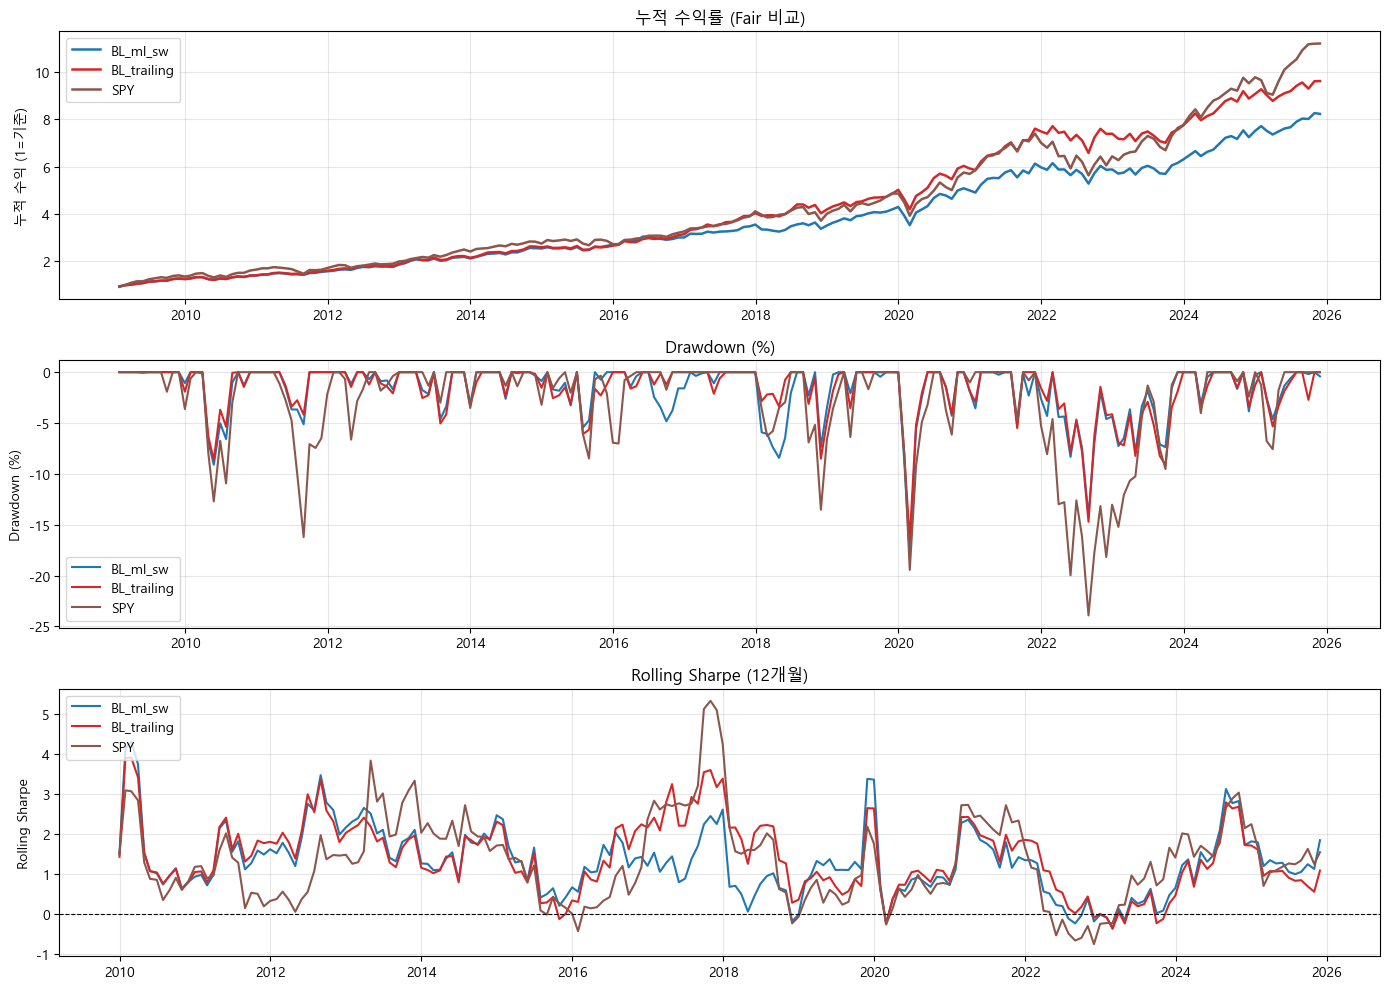


✅ 02a Stockwise BL 백테스트 sanity check 완료
  시각화 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02a_stockwise\bl_sanity_check.png

판정 기준:
  - BL_trailing Sharpe ≈ 1.0~1.2 → 서윤범 99 재현 OK
  - BL_ml_sw Sharpe > BL_trailing → ML 통합 효과 양성
  - BL_ml_sw Sharpe < BL_trailing → ML 통합 효과 미미 또는 역효과

💡 정식 6 시나리오 (+EW, +Mcap, +BL_ml_cs) 평가는 02b 완료 후 03 노트북.


In [75]:
# §6-5. 시각화 (누적 수익률 + Drawdown + Rolling Sharpe)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

COLORS = {
    'BL_ml_sw': '#1f77b4',
    'BL_trailing': '#d62728',
    'SPY': '#8c564b',
}

returns_dict = {
    'BL_ml_sw': ret_ml_fair,
    'BL_trailing': ret_tr_fair,
    'SPY': ret_spy_fair,
}

# 1. 누적 수익률
ax = axes[0]
for s, r in returns_dict.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        ax.plot(cum.index, cum.values, label=s, color=COLORS[s], linewidth=1.8)
ax.set_title('누적 수익률 (Fair 비교)', fontsize=12)
ax.set_ylabel('누적 수익 (1=기준)')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[1]
for s, r in returns_dict.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        dd = (cum / cum.cummax() - 1) * 100
        ax.plot(dd.index, dd.values, label=s, color=COLORS[s], linewidth=1.5)
ax.set_title('Drawdown (%)', fontsize=12)
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)

# 3. Rolling Sharpe (12 개월)
ax = axes[2]
for s, r in returns_dict.items():
    if len(r) >= 12:
        roll_sharpe = r.rolling(12).apply(
            lambda x: x.mean() / x.std() * np.sqrt(12) if x.std() > 0 else np.nan
        )
        ax.plot(roll_sharpe.index, roll_sharpe.values, label=s, color=COLORS[s], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling Sharpe (12개월)', fontsize=12)
ax.set_ylabel('Rolling Sharpe')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_sanity_check.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n✅ 02a Stockwise BL 백테스트 sanity check 완료')
print(f'  시각화 저장: {OUT_DIR / "bl_sanity_check.png"}')
print()
print('판정 기준:')
print(f'  - BL_trailing Sharpe ≈ 1.0~1.2 → 서윤범 99 재현 OK')
print(f'  - BL_ml_sw Sharpe > BL_trailing → ML 통합 효과 양성')
print(f'  - BL_ml_sw Sharpe < BL_trailing → ML 통합 효과 미미 또는 역효과')
print()
print('💡 정식 6 시나리오 (+EW, +Mcap, +BL_ml_cs) 평가는 02b 완료 후 03 노트북.')

In [76]:
# §6-6. Hit rate 분석 — ML vs Trailing 의 양극단 30% 식별 정확도
# (BL_ml_sw 가 BL_trailing 보다 약한 이유 진단)

print('=' * 70)
print('  Hit Rate 분석: ML 예측 vs Trailing 이 실제 양극단 30% 를 잘 식별하는가?')
print('=' * 70)

# ─── 1. Pivot 데이터 준비 (3 종) ───
# (a) ML 예측: ml_pred_pivot 이미 §6-1 에서 생성됨 (reb_dates × tickers)

# (b) 실제 vol (y_true): ensemble_sw 의 y_true 를 같은 형식으로
ens_truth = ensemble_sw.copy()
ens_truth['month'] = ens_truth['date'].dt.to_period('M')
truth_monthly = ens_truth.groupby(['ticker', 'month'])['y_true'].last().reset_index()
truth_monthly['rebalance_date'] = truth_monthly['month'].map(month_to_eom)
truth_monthly = truth_monthly.dropna(subset=['rebalance_date'])
actual_pivot = truth_monthly.pivot_table(
    index='rebalance_date', columns='ticker', values='y_true'
)

# (c) Trailing vol_21d (panel 의 reb_date 시점 값)
trailing_pivot = panel.pivot_table(index='date', columns='ticker', values='vol_21d')
trailing_pivot = trailing_pivot.reindex(reb_dates)

print(f'ml_pred_pivot:  {ml_pred_pivot.shape}')
print(f'actual_pivot:   {actual_pivot.shape}')
print(f'trailing_pivot: {trailing_pivot.shape}')


# ─── 2. Hit rate 계산 함수 ───
from scipy.stats import spearmanr

def compute_hit_rates(predictor_pivot, actual_pivot, reb_dates, pct=0.30, min_n=30):
    """매 reb_date 의 양극단 30% 일치율 + Spearman 반환."""
    rows = []
    for reb_date in reb_dates:
        if reb_date not in predictor_pivot.index or reb_date not in actual_pivot.index:
            continue
        pred = predictor_pivot.loc[reb_date].dropna()
        actual = actual_pivot.loc[reb_date].dropna()
        common = pred.index.intersection(actual.index)
        if len(common) < min_n:
            continue
        pred_c = pred.loc[common]
        actual_c = actual.loc[common]
        n_group = max(1, int(len(common) * pct))

        pred_low = set(pred_c.nsmallest(n_group).index)
        pred_high = set(pred_c.nlargest(n_group).index)
        actual_low = set(actual_c.nsmallest(n_group).index)
        actual_high = set(actual_c.nlargest(n_group).index)

        rho, _ = spearmanr(pred_c.values, actual_c.values)

        rows.append({
            'date': reb_date,
            'low_hit': len(pred_low & actual_low) / n_group,
            'high_hit': len(pred_high & actual_high) / n_group,
            'spearman': rho,
            'n_universe': len(common),
            'n_group': n_group,
        })
    return pd.DataFrame(rows).set_index('date')


# ML 예측 hit rate
hr_ml = compute_hit_rates(ml_pred_pivot, actual_pivot, reb_dates, pct=0.30)
# Trailing vol_21d hit rate
hr_tr = compute_hit_rates(trailing_pivot, actual_pivot, reb_dates, pct=0.30)

print(f'\n분석 가능 시점:')
print(f'  ML:       {len(hr_ml)} 개월')
print(f'  Trailing: {len(hr_tr)} 개월')

# ─── 3. 평균 통계 비교 ───
print(f'\n=== 평균 Hit Rate 비교 ===')
print(f'{"":<25}{"ML (02a)":<15}{"Trailing":<15}{"차이 (ML-TR)":<15}')
print('-' * 70)
for col, label in [('low_hit', 'Low vol hit (long)'),
                    ('high_hit', 'High vol hit (short)'),
                    ('spearman', 'Spearman rank corr')]:
    ml_val = hr_ml[col].mean()
    tr_val = hr_tr[col].mean()
    diff = ml_val - tr_val
    print(f'{label:<25}{ml_val:<15.4f}{tr_val:<15.4f}{diff:+.4f}')
print(f'\nRandom baseline (uniform): low/high = 0.30 (= pct)')
print(f'Random Spearman:          0.000')

  Hit Rate 분석: ML 예측 vs Trailing 이 실제 양극단 30% 를 잘 식별하는가?
ml_pred_pivot:  (204, 613)
actual_pivot:   (204, 613)
trailing_pivot: (204, 646)

분석 가능 시점:
  ML:       204 개월
  Trailing: 204 개월

=== 평균 Hit Rate 비교 ===
                         ML (02a)       Trailing       차이 (ML-TR)     
----------------------------------------------------------------------
Low vol hit (long)       0.6342         0.5901         +0.0441
High vol hit (short)     0.6632         0.6261         +0.0371
Spearman rank corr       0.6883         0.6159         +0.0724

Random baseline (uniform): low/high = 0.30 (= pct)
Random Spearman:          0.000


In [77]:
# ─── 4. 시기별 분해 ───
print('\n=== 시기별 평균 Hit Rate ===')
PERIODS_HR = {
    'GFC 회복 (09~11)': ('2009-01', '2011-12'),
    '강세장 (12~19)':   ('2012-01', '2019-12'),
    'COVID (20)':       ('2020-01', '2020-12'),
    '긴축 (21~22)':     ('2021-01', '2022-12'),
    '회복·AI (23~25)':  ('2023-01', '2025-12'),
}

period_rows = []
for pname, (start, end) in PERIODS_HR.items():
    ml_sub = hr_ml.loc[start:end]
    tr_sub = hr_tr.loc[start:end]
    if len(ml_sub) == 0:
        continue
    period_rows.append({
        'period': pname,
        'n_months': len(ml_sub),
        'ML_low': ml_sub['low_hit'].mean(),
        'TR_low': tr_sub['low_hit'].mean(),
        'ML_high': ml_sub['high_hit'].mean(),
        'TR_high': tr_sub['high_hit'].mean(),
        'ML_rho': ml_sub['spearman'].mean(),
        'TR_rho': tr_sub['spearman'].mean(),
    })

period_df = pd.DataFrame(period_rows).set_index('period')
print(period_df.round(4).to_string())


=== 시기별 평균 Hit Rate ===
                n_months   ML_low   TR_low  ML_high  TR_high   ML_rho   TR_rho
period                                                                        
GFC 회복 (09~11)        36 0.713400 0.685000 0.688000 0.676900 0.761900 0.726800
강세장 (12~19)           96 0.616300 0.559100 0.643600 0.594000 0.660500 0.566100
COVID (20)            12 0.601600 0.594300 0.670900 0.692100 0.662000 0.671900
긴축 (21~22)            24 0.639200 0.598600 0.712500 0.675600 0.732900 0.672000
회복·AI (23~25)         36 0.610700 0.571000 0.654900 0.605800 0.668200 0.581800


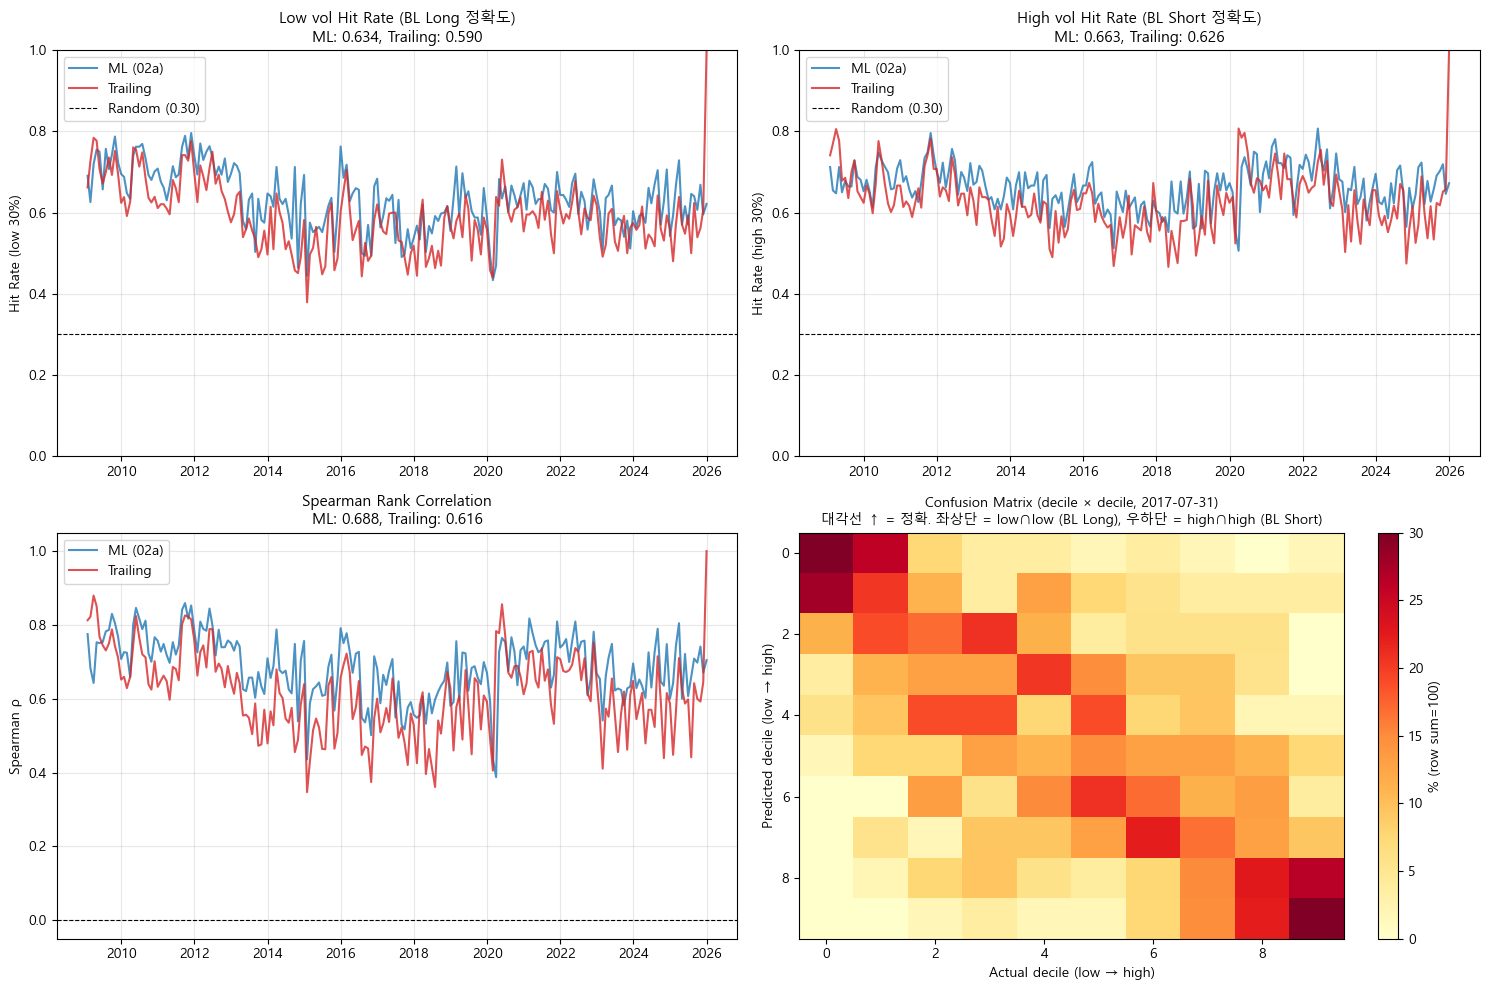

In [78]:
# ─── 5. 시각화 (Hit Rate 시계열 + Confusion Matrix) ───
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Low vol hit rate 시계열
ax = axes[0, 0]
ax.plot(hr_ml.index, hr_ml['low_hit'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['low_hit'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0.30, color='black', linewidth=0.8, linestyle='--', label='Random (0.30)')
ax.set_title(f'Low vol Hit Rate (BL Long 정확도)\nML: {hr_ml["low_hit"].mean():.3f}, '
             f'Trailing: {hr_tr["low_hit"].mean():.3f}', fontsize=11)
ax.set_ylabel('Hit Rate (low 30%)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# (2) High vol hit rate 시계열
ax = axes[0, 1]
ax.plot(hr_ml.index, hr_ml['high_hit'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['high_hit'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0.30, color='black', linewidth=0.8, linestyle='--', label='Random (0.30)')
ax.set_title(f'High vol Hit Rate (BL Short 정확도)\nML: {hr_ml["high_hit"].mean():.3f}, '
             f'Trailing: {hr_tr["high_hit"].mean():.3f}', fontsize=11)
ax.set_ylabel('Hit Rate (high 30%)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# (3) Spearman rank corr 시계열
ax = axes[1, 0]
ax.plot(hr_ml.index, hr_ml['spearman'], label='ML (02a)', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax.plot(hr_tr.index, hr_tr['spearman'], label='Trailing', color='#d62728', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Spearman Rank Correlation\nML: {hr_ml["spearman"].mean():.3f}, '
             f'Trailing: {hr_tr["spearman"].mean():.3f}', fontsize=11)
ax.set_ylabel('Spearman ρ'); ax.legend(); ax.grid(alpha=0.3)

# (4) Decile × Decile confusion matrix (sample month)
sample_date = reb_dates[len(reb_dates) // 2]   # 중간 시점
if sample_date in ml_pred_pivot.index and sample_date in actual_pivot.index:
    pred = ml_pred_pivot.loc[sample_date].dropna()
    actual = actual_pivot.loc[sample_date].dropna()
    common = pred.index.intersection(actual.index)
    if len(common) >= 30:
        pred_c = pred.loc[common]; actual_c = actual.loc[common]
        # decile (10 분위)
        pred_dec = pd.qcut(pred_c, 10, labels=False, duplicates='drop')
        actual_dec = pd.qcut(actual_c, 10, labels=False, duplicates='drop')
        cm = pd.crosstab(pred_dec, actual_dec, normalize='index') * 100   # row 정규화 (%)

        ax = axes[1, 1]
        im = ax.imshow(cm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=30)
        ax.set_title(f'Confusion Matrix (decile × decile, {sample_date.date()})\n'
                     f'대각선 ↑ = 정확. 좌상단 = low∩low (BL Long), 우하단 = high∩high (BL Short)',
                     fontsize=10)
        ax.set_xlabel('Actual decile (low → high)')
        ax.set_ylabel('Predicted decile (low → high)')
        plt.colorbar(im, ax=ax, label='% (row sum=100)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hit_rate_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [79]:
# ─── 6. 결론 ───
print('\n' + '=' * 70)
print('  진단 결론')
print('=' * 70)

ml_low = hr_ml['low_hit'].mean()
tr_low = hr_tr['low_hit'].mean()
ml_high = hr_ml['high_hit'].mean()
tr_high = hr_tr['high_hit'].mean()
ml_rho = hr_ml['spearman'].mean()
tr_rho = hr_tr['spearman'].mean()

print(f'\n[Low vol 식별] (BL Long 정확도)')
if ml_low > tr_low:
    print(f'  ML 우위: {ml_low:.3f} > {tr_low:.3f} (+{(ml_low-tr_low)*100:.1f}%p)')
else:
    print(f'  Trailing 우위: {tr_low:.3f} > {ml_low:.3f} ({(ml_low-tr_low)*100:+.1f}%p)')

print(f'\n[High vol 식별] (BL Short 정확도)')
if ml_high > tr_high:
    print(f'  ML 우위: {ml_high:.3f} > {tr_high:.3f} (+{(ml_high-tr_high)*100:.1f}%p)')
else:
    print(f'  Trailing 우위: {tr_high:.3f} > {ml_high:.3f} ({(ml_high-tr_high)*100:+.1f}%p)')

print(f'\n[Spearman 전체 rank]')
if ml_rho > tr_rho:
    print(f'  ML 우위: {ml_rho:.3f} > {tr_rho:.3f}')
else:
    print(f'  Trailing 우위: {tr_rho:.3f} > {ml_rho:.3f}')

print(f'\n[BL 성과 (§6-4 결과 요약)]')
print(f'  BL_ml_sw Sharpe:    {metrics_table.loc["BL_ml_sw", "sharpe"]:.3f}')
print(f'  BL_trailing Sharpe: {metrics_table.loc["BL_trailing", "sharpe"]:.3f}')
print(f'  → ML 통합 효과 {delta_sharpe:+.3f}')

print(f'\n[해석]')
if (ml_low <= tr_low and ml_high <= tr_high):
    print('  ✅ Hit rate 도 ML < Trailing → BL 성과 차이 자연스럽게 설명')
    print('  → ML 예측은 RMSE 는 약간 우위지만 RANKING (BL P 행렬 핵심) 은 trailing 만 못함')
elif (ml_low > tr_low or ml_high > tr_high):
    print('  ⚠️ Hit rate 는 ML 가 우위 → BL 성과 negative 이유 다른 곳에')
    print('  → P 행렬 가중치, omega, 또는 시기별 효과 추가 진단 필요')


  진단 결론

[Low vol 식별] (BL Long 정확도)
  ML 우위: 0.634 > 0.590 (+4.4%p)

[High vol 식별] (BL Short 정확도)
  ML 우위: 0.663 > 0.626 (+3.7%p)

[Spearman 전체 rank]
  ML 우위: 0.688 > 0.616

[BL 성과 (§6-4 결과 요약)]
  BL_ml_sw Sharpe:    1.122
  BL_trailing Sharpe: 1.207
  → ML 통합 효과 -0.085

[해석]
  ⚠️ Hit rate 는 ML 가 우위 → BL 성과 negative 이유 다른 곳에
  → P 행렬 가중치, omega, 또는 시기별 효과 추가 진단 필요


In [80]:
# §6-7. Long-Short 그룹의 실제 다음달 수익률 (BL 알고리즘 우회)

# ─── 1. mcap pivot 준비 ───
mcap_pivot = panel.pivot_table(index='date', columns='ticker', values='mcap_value')
mcap_pivot_reb = mcap_pivot.reindex(reb_dates).ffill()

# ─── 2. LS 수익률 계산 (단순 평균 + mcap 가중) ───
def compute_ls_returns(predictor_pivot, forward_rets, mcap_pivot, reb_dates, pct=0.30, min_n=30):
    rows = []
    for reb_date in reb_dates:
        if reb_date not in predictor_pivot.index or reb_date not in forward_rets.index:
            continue
        pred = predictor_pivot.loc[reb_date].dropna()
        ret = forward_rets.loc[reb_date].dropna()
        common = pred.index.intersection(ret.index)
        if len(common) < min_n:
            continue
        pred_c = pred.loc[common]
        ret_c = ret.loc[common]
        n_group = max(1, int(len(common) * pct))

        low_set = pred_c.nsmallest(n_group).index
        high_set = pred_c.nlargest(n_group).index

        # 단순 평균
        ret_low_eq = ret_c.loc[low_set].mean()
        ret_high_eq = ret_c.loc[high_set].mean()

        # mcap 가중 (BL P 행렬 일관)
        ret_low_mw = ret_high_mw = np.nan
        if reb_date in mcap_pivot.index:
            mcap = mcap_pivot.loc[reb_date].dropna()
            mcap_low = mcap.reindex(low_set).dropna()
            mcap_high = mcap.reindex(high_set).dropna()
            if len(mcap_low) > 0 and mcap_low.sum() > 0:
                w_low = mcap_low / mcap_low.sum()
                ret_low_mw = (ret_c.reindex(w_low.index) * w_low).sum()
            if len(mcap_high) > 0 and mcap_high.sum() > 0:
                w_high = mcap_high / mcap_high.sum()
                ret_high_mw = (ret_c.reindex(w_high.index) * w_high).sum()

        rows.append({
            'date': reb_date,
            'low_eq': ret_low_eq, 'high_eq': ret_high_eq,
            'ls_eq': ret_low_eq - ret_high_eq,
            'low_mw': ret_low_mw, 'high_mw': ret_high_mw,
            'ls_mw': ret_low_mw - ret_high_mw if pd.notna(ret_low_mw) and pd.notna(ret_high_mw) else np.nan,
            'avg_mcap_low': mcap.reindex(low_set).mean() if reb_date in mcap_pivot.index else np.nan,
            'avg_mcap_high': mcap.reindex(high_set).mean() if reb_date in mcap_pivot.index else np.nan,
            'avg_mcap_all': mcap.mean() if reb_date in mcap_pivot.index else np.nan,
        })
    return pd.DataFrame(rows).set_index('date')

ls_ml = compute_ls_returns(ml_pred_pivot, forward_rets, mcap_pivot_reb, reb_dates)
ls_tr = compute_ls_returns(trailing_pivot, forward_rets, mcap_pivot_reb, reb_dates)

# ─── 3. 통계 비교 ───
print('=' * 85)
print('  Long-Short 그룹의 실제 다음달 평균 수익률 (BL 우회, raw 수익률)')
print('=' * 85)
print()
print(f'{"":<40}{"ML (02a)":<14}{"Trailing":<14}{"차이":<14}')
print('-' * 85)
for col, label, scale in [
    ('low_eq',   'Long 30% eq-weight (월평균)',  100),
    ('high_eq',  'Short 30% eq-weight (월평균)', 100),
    ('ls_eq',    '⭐ LS spread eq-weight (월)',   100),
    ('low_mw',   'Long 30% mcap-weight (월평균)', 100),
    ('high_mw',  'Short 30% mcap-weight (월평균)',100),
    ('ls_mw',    '⭐ LS spread mcap-weight (월)', 100),
]:
    ml_v = ls_ml[col].mean() * scale
    tr_v = ls_tr[col].mean() * scale
    print(f'{label:<40}{ml_v:>+9.3f}%    {tr_v:>+9.3f}%    {ml_v-tr_v:>+9.3f}%p')

print()
print('=== Annualized (×12, 연환산) ===')
ml_annual_eq = ls_ml['ls_eq'].mean() * 12 * 100
tr_annual_eq = ls_tr['ls_eq'].mean() * 12 * 100
ml_annual_mw = ls_ml['ls_mw'].mean() * 12 * 100
tr_annual_mw = ls_tr['ls_mw'].mean() * 12 * 100
print(f'  ML LS spread (eq):     {ml_annual_eq:+.2f}%/year')
print(f'  Trailing LS spread (eq):  {tr_annual_eq:+.2f}%/year')
print(f'  ML LS spread (mw):     {ml_annual_mw:+.2f}%/year   ← BL 과 가장 가까움')
print(f'  Trailing LS spread (mw):  {tr_annual_mw:+.2f}%/year   ← BL 과 가장 가까움')
print(f'  ML - Trailing (mw):       {ml_annual_mw - tr_annual_mw:+.2f}%p')

  Long-Short 그룹의 실제 다음달 평균 수익률 (BL 우회, raw 수익률)

                                        ML (02a)      Trailing      차이            
-------------------------------------------------------------------------------------
Long 30% eq-weight (월평균)                   +1.224%       +1.385%       -0.161%p
Short 30% eq-weight (월평균)                +167.766%     +611.876%     -444.110%p
⭐ LS spread eq-weight (월)                -166.542%     -610.491%     +443.949%p
Long 30% mcap-weight (월평균)                 +1.088%       +1.223%       -0.135%p
Short 30% mcap-weight (월평균)                +1.883%       +1.626%       +0.256%p
⭐ LS spread mcap-weight (월)                -0.795%       -0.403%       -0.391%p

=== Annualized (×12, 연환산) ===
  ML LS spread (eq):     -1998.50%/year
  Trailing LS spread (eq):  -7325.89%/year
  ML LS spread (mw):     -9.53%/year   ← BL 과 가장 가까움
  Trailing LS spread (mw):  -4.84%/year   ← BL 과 가장 가까움
  ML - Trailing (mw):       -4.70%p


In [81]:
# §6-7-2. 시총 분포 분석 (Long 30% 그룹 평균 시총)
print('=' * 85)
print('  Long 30% 그룹의 평균 시총 (B$ 단위)')
print('=' * 85)
print(f'  ML long 30% 평균 mcap:       ${ls_ml["avg_mcap_low"].mean() / 1e9:.1f} B')
print(f'  Trailing long 30% 평균 mcap: ${ls_tr["avg_mcap_low"].mean() / 1e9:.1f} B')
print(f'  All universe 평균 mcap:      ${ls_ml["avg_mcap_all"].mean() / 1e9:.1f} B')
print()
print(f'  ML high 30% 평균 mcap:       ${ls_ml["avg_mcap_high"].mean() / 1e9:.1f} B')
print(f'  Trailing high 30% 평균 mcap: ${ls_tr["avg_mcap_high"].mean() / 1e9:.1f} B')

# 해석: ML 이 시총 작은 종목을 더 low-vol 로 분류하면 P 가중치 분산 효과
diff_low = ls_ml["avg_mcap_low"].mean() - ls_tr["avg_mcap_low"].mean()
print(f'\n해석:')
if diff_low < -10e9:
    print(f'  ML 이 시총 작은 종목을 long 으로 더 많이 → P 가중치 분산 → BL 성과 ↓ 가능성')
elif diff_low > 10e9:
    print(f'  ML 이 시총 큰 종목을 long 으로 더 많이 → 더 안정적 가중치')
else:
    print(f'  시총 분포 차이 작음 → 다른 원인 추적 필요')

  Long 30% 그룹의 평균 시총 (B$ 단위)
  ML long 30% 평균 mcap:       $51.2 B
  Trailing long 30% 평균 mcap: $49.0 B
  All universe 평균 mcap:      $38.6 B

  ML high 30% 평균 mcap:       $25.6 B
  Trailing high 30% 평균 mcap: $28.9 B

해석:
  시총 분포 차이 작음 → 다른 원인 추적 필요


  시기별 LS spread (연환산 %)
                 n  ML_LS_eq_%y   TR_LS_eq_%y  ML_LS_mw_%y  TR_LS_mw_%y
period                                                                 
GFC 회복 (09~11)  36 -1042.960000   -949.630000   -13.260000   -13.110000
강세장 (12~19)     96 -3822.080000 -15119.100000    -3.550000     3.170000
COVID (20)      12   -47.350000    -49.390000   -21.590000   -18.970000
긴축 (21~22)      24    -1.900000     -7.160000     1.880000     8.910000
회복·AI (23~25)   35   -17.570000    -22.030000   -25.820000   -22.870000


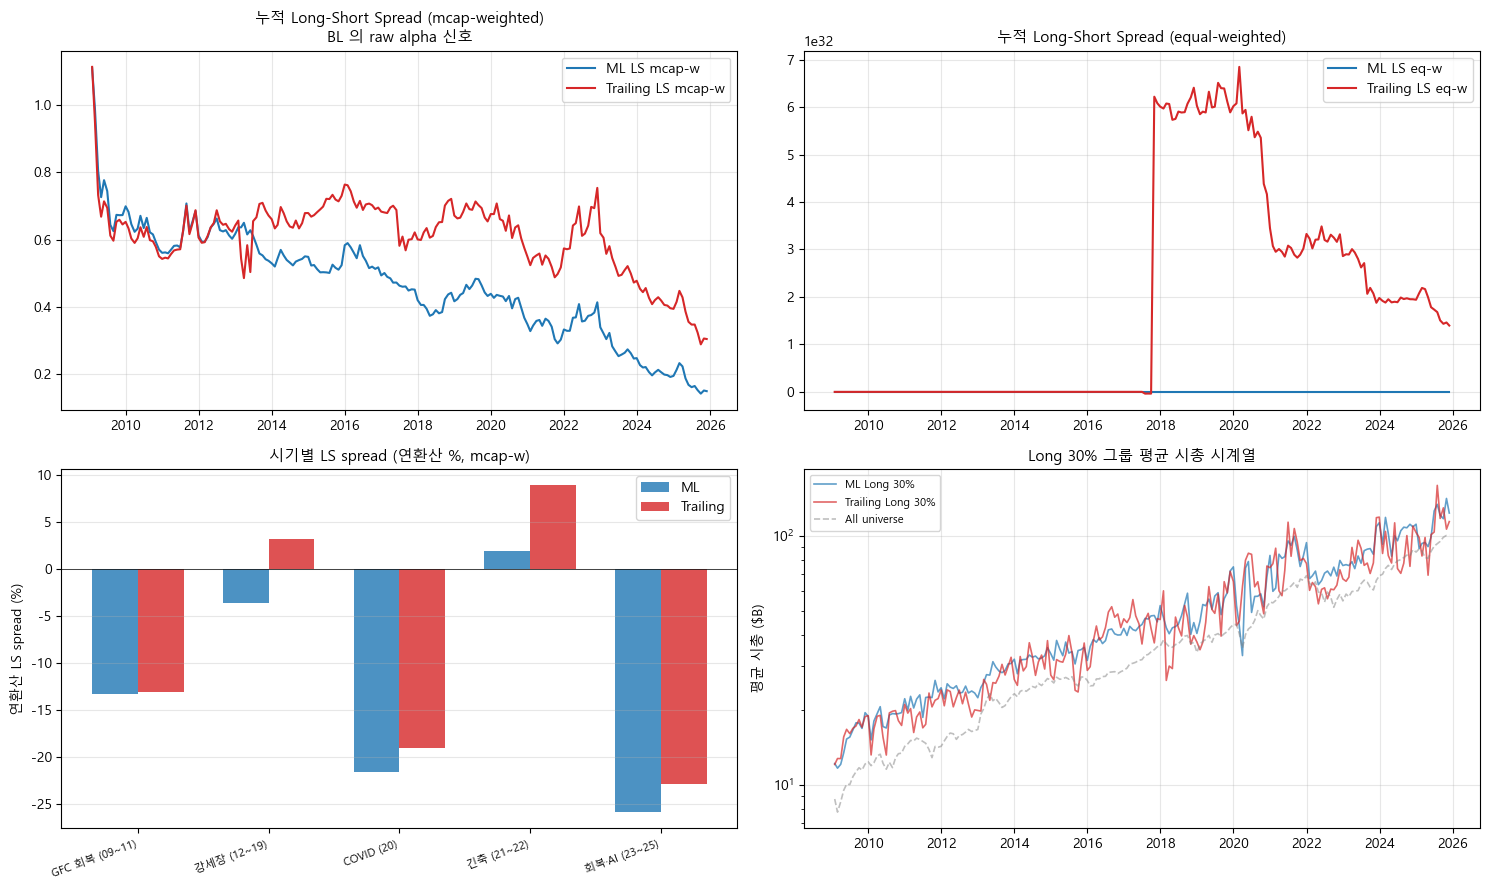

In [82]:
# §6-7-3. 시기별 LS spread + 시각화
PERIODS_LS = {
    'GFC 회복 (09~11)': ('2009-01', '2011-12'),
    '강세장 (12~19)':   ('2012-01', '2019-12'),
    'COVID (20)':       ('2020-01', '2020-12'),
    '긴축 (21~22)':     ('2021-01', '2022-12'),
    '회복·AI (23~25)':  ('2023-01', '2025-12'),
}

period_ls_rows = []
for pname, (start, end) in PERIODS_LS.items():
    ml_sub = ls_ml.loc[start:end]
    tr_sub = ls_tr.loc[start:end]
    if len(ml_sub) == 0:
        continue
    period_ls_rows.append({
        'period': pname,
        'n': len(ml_sub),
        'ML_LS_eq_%y':  ml_sub['ls_eq'].mean() * 12 * 100,
        'TR_LS_eq_%y':  tr_sub['ls_eq'].mean() * 12 * 100,
        'ML_LS_mw_%y':  ml_sub['ls_mw'].mean() * 12 * 100,
        'TR_LS_mw_%y':  tr_sub['ls_mw'].mean() * 12 * 100,
    })

period_ls_df = pd.DataFrame(period_ls_rows).set_index('period')
print('=' * 85)
print('  시기별 LS spread (연환산 %)')
print('=' * 85)
print(period_ls_df.round(2).to_string())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# (1) 누적 LS spread (mcap-w, BL 가장 가까움)
ax = axes[0, 0]
cum_ml_mw = (1 + ls_ml['ls_mw'].fillna(0)).cumprod()
cum_tr_mw = (1 + ls_tr['ls_mw'].fillna(0)).cumprod()
ax.plot(cum_ml_mw.index, cum_ml_mw.values, label='ML LS mcap-w', color='#1f77b4', linewidth=1.5)
ax.plot(cum_tr_mw.index, cum_tr_mw.values, label='Trailing LS mcap-w', color='#d62728', linewidth=1.5)
ax.set_title('누적 Long-Short Spread (mcap-weighted)\nBL 의 raw alpha 신호', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

# (2) 누적 LS spread (eq-w)
ax = axes[0, 1]
cum_ml_eq = (1 + ls_ml['ls_eq'].fillna(0)).cumprod()
cum_tr_eq = (1 + ls_tr['ls_eq'].fillna(0)).cumprod()
ax.plot(cum_ml_eq.index, cum_ml_eq.values, label='ML LS eq-w', color='#1f77b4', linewidth=1.5)
ax.plot(cum_tr_eq.index, cum_tr_eq.values, label='Trailing LS eq-w', color='#d62728', linewidth=1.5)
ax.set_title('누적 Long-Short Spread (equal-weighted)', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

# (3) 시기별 LS spread (mcap-w) bar
ax = axes[1, 0]
x = np.arange(len(period_ls_df.index))
width = 0.35
ax.bar(x - width/2, period_ls_df['ML_LS_mw_%y'], width, label='ML', color='#1f77b4', alpha=0.8)
ax.bar(x + width/2, period_ls_df['TR_LS_mw_%y'], width, label='Trailing', color='#d62728', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(period_ls_df.index, rotation=20, ha='right', fontsize=8)
ax.set_title('시기별 LS spread (연환산 %, mcap-w)', fontsize=11)
ax.set_ylabel('연환산 LS spread (%)')
ax.axhline(0, color='black', linewidth=0.5); ax.legend(); ax.grid(axis='y', alpha=0.3)

# (4) Long/Short 그룹 평균 시총 시계열
ax = axes[1, 1]
ax.plot(ls_ml.index, ls_ml['avg_mcap_low'] / 1e9, label='ML Long 30%', color='#1f77b4', linewidth=1.2, alpha=0.7)
ax.plot(ls_tr.index, ls_tr['avg_mcap_low'] / 1e9, label='Trailing Long 30%', color='#d62728', linewidth=1.2, alpha=0.7)
ax.plot(ls_ml.index, ls_ml['avg_mcap_all'] / 1e9, label='All universe', color='gray', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_title('Long 30% 그룹 평균 시총 시계열', fontsize=11)
ax.set_ylabel('평균 시총 ($B)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(OUT_DIR / 'paradox_analysis.png', dpi=100, bbox_inches='tight')
plt.show()